SETUP AND IMPORTS

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install xgboost shap --quiet

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

#For Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

#FOr Random Forest
from sklearn.ensemble import RandomForestClassifier

#For XG Boost Classifier
from xgboost import XGBClassifier

from sklearn.metrics import RocCurveDisplay

import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

!pip install shap --quiet
import shap


In [ ]:
DATA_DIR = "/content/drive/MyDrive/eicu-database"
OUT_DIR  = "/content/drive/MyDrive/eicu-database/scaled"
os.makedirs(OUT_DIR, exist_ok=True)


N_PER_CLASS = 500          # set to 1000 for a 2000-patient run
CHUNK_SIZE  = 200_000
RANDOM_SEED = 42

CHUNK AND LOAD

In [ ]:
print("Loading patient dataset...")
patient = pd.read_csv(f"{DATA_DIR}/patient.csv.gz", compression="gzip")
patient["age"] = patient["age"].replace("> 89", 90)
patient["age"] = pd.to_numeric(patient["age"], errors="coerce")

patient = patient[patient["unitdischargestatus"].isin(["Alive", "Expired"])]
alive   = patient[patient["unitdischargestatus"] == "Alive"]
expired = patient[patient["unitdischargestatus"] == "Expired"]

patient_scaled = pd.concat([
    alive.sample(n=min(N_PER_CLASS, len(alive)), random_state=RANDOM_SEED),
    expired.sample(n=min(N_PER_CLASS, len(expired)), random_state=RANDOM_SEED)
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

core_cols = ["patientunitstayid","age","gender","ethnicity",
             "admissionheight","admissionweight","unitdischargestatus"]
patient_scaled[core_cols].to_csv(f"{OUT_DIR}/patient_scaled.csv", index=False)

print(patient_scaled["unitdischargestatus"].value_counts())
print("Saved patient_scaled.csv")

Loading patient dataset...
unitdischargestatus
Expired    500
Alive      500
Name: count, dtype: int64
Saved patient_scaled.csv


PULL VITALS FOR ALL PATIENT ID

In [ ]:
selected_ids = set(patient_scaled["patientunitstayid"].unique())
print(f"\nFetching vitals for {len(selected_ids):,} patients...")

vitals_chunks = []
vitals_path   = f"{DATA_DIR}/vitalPeriodic.csv.gz"

for chunk in pd.read_csv(
    vitals_path,
    compression="gzip",
    chunksize=CHUNK_SIZE,
    usecols=[
        "patientunitstayid", "observationoffset",
        "heartrate", "systemicmean", "respiration", "sao2"
    ]
):
    filtered = chunk[chunk["patientunitstayid"].isin(selected_ids)]
    if not filtered.empty:
        vitals_chunks.append(filtered)

vitals_scaled = pd.concat(vitals_chunks, ignore_index=True)
print(f"Vitals rows: {len(vitals_scaled):,}")
print(f"Patients with vitals: {vitals_scaled['patientunitstayid'].nunique():,}")

vitals_scaled.to_csv(f"{OUT_DIR}/vitals_scaled.csv", index=False)
print(f"Saved: {OUT_DIR}/vitals_scaled.csv")



Fetching vitals for 1,000 patients...
Vitals rows: 932,757
Patients with vitals: 963
Saved: /content/drive/MyDrive/eicu-database/scaled/vitals_scaled.csv


In [ ]:
sepsis_unified_map = {
    "Lactate":      ["lactate", "lactic acid", "Plasma Lactic Acid Ven"],
    "WBC":          ["WBC x 1000", "WBC", "wbc", "WBC "],
    "Neutrophils":  ["NEUT", "Neut", "neut", "Neutrophil", "neutrophils",
                     "Neuts", "Neuts %", "-bands", "band neutrophils",
                     "ABS NEUTS", "ABSOL NEUT", "Abs Neuts", "Abso Neuts",
                     "Absol Neut", "Absol neut", "absol neut",
                     "absol neutrophils", "absolute neut",
                     "absolute neutrophil", "neuts absol"],
    "CRP":          ["CRP", "CRP-hs"],
    "BUN":          ["BUN", "bun"],
    "Creatinine":   ["Creatinine", "creatinine", "CRT w Est GFR",
                     "Creatinene w Est GFR", "Creatinine w Est GFR",
                     "Creatinine w GFR", "Creatinine w/ Est GFR",
                     "Crt  w Est GFR", "Crt c Est GFR", "Crt w Est GFR",
                     "Crt w GFR", "creat w/est GFR"],
    "AST":          ["AST (SGOT)"],
    "ALT":          ["ALT (SGPT)"],
    "Bilirubin":    ["total bilirubin", "indirect bilirubin"],
    "Platelets":    ["platelets x 1000", "plt estiimate"],
    "D_Dimer":      ["D-Dimer", "DDimer", "d- Dimer"],
    "pH":           ["pH", "Venous pH", "WB Ionized Ca+ pH",
                     "WB Ionized Calcium pH", "WB ion calcium PH",
                     "WB ionized Calcium pH"],
    "PaO2":         ["paO2"],
    "PaCO2":        ["paCO2"],
    "Bicarbonate":  ["bicarbonate", "HCO3"],
}
lab_name_to_canonical = {}
for canonical, raw_names in sepsis_unified_map.items():
    for raw in raw_names:
        lab_name_to_canonical[raw] = canonical

all_raw_names = set(lab_name_to_canonical.keys())


PULL LABS FOR ALL SELECTED PATIENTS

In [ ]:
print(f"\nFetching labs for {len(selected_ids):,} patients...")
lab_chunks = []
lab_path   = f"{DATA_DIR}/lab.csv.gz"

for chunk in pd.read_csv(
    lab_path,
    compression="gzip",
    chunksize=CHUNK_SIZE,
    usecols=["patientunitstayid", "labname", "labresult", "labresultoffset"]
):
    filtered = chunk[
        chunk["patientunitstayid"].isin(selected_ids) &
        chunk["labname"].isin(all_raw_names)
    ]
    if not filtered.empty:
        lab_chunks.append(filtered)

labs_scaled = pd.concat(lab_chunks, ignore_index=True)


Fetching labs for 1,000 patients...


MAP RAW LAB NAMES TO CANONICAL NAMES

In [ ]:
labs_scaled["lab_canonical"] = labs_scaled["labname"].map(lab_name_to_canonical)
labs_scaled = labs_scaled.drop(columns=["labname"])

print(f"Lab rows: {len(labs_scaled):,}")
print(f"Patients with labs: {labs_scaled['patientunitstayid'].nunique():,}")
print("\nLab counts by canonical name:")
print(labs_scaled["lab_canonical"].value_counts())

labs_scaled.to_csv(f"{OUT_DIR}/labs_scaled.csv", index=False)
print(f"\nSaved: {OUT_DIR}/labs_scaled.csv")


Lab rows: 60,811
Patients with labs: 958

Lab counts by canonical name:
lab_canonical
Bicarbonate    10733
Creatinine      7150
BUN             7110
Platelets       6313
WBC             6236
PaO2            4085
pH              4047
PaCO2           4008
ALT             2829
AST             2822
Bilirubin       2766
Lactate         2065
Neutrophils      572
CRP               75
Name: count, dtype: int64

Saved: /content/drive/MyDrive/eicu-database/scaled/labs_scaled.csv


COVERAGE REPORT

In [ ]:
print("\n=== COVERAGE REPORT ===")
total = len(patient_scaled)
has_vitals = vitals_scaled["patientunitstayid"].nunique()
has_labs   = labs_scaled["patientunitstayid"].nunique()
has_both   = len(
    set(vitals_scaled["patientunitstayid"].unique()) &
    set(labs_scaled["patientunitstayid"].unique())
)

print(f"Total patients:          {total:,}")
print(f"With vitals data:        {has_vitals:,}  ({has_vitals/total*100:.1f}%)")
print(f"With labs data:          {has_labs:,}  ({has_labs/total*100:.1f}%)")
print(f"With BOTH vitals & labs: {has_both:,}  ({has_both/total*100:.1f}%)")
print("\nStage 1 complete. Files saved to:", OUT_DIR)


=== COVERAGE REPORT ===
Total patients:          1,000
With vitals data:        963  (96.3%)
With labs data:          958  (95.8%)
With BOTH vitals & labs: 934  (93.4%)

Stage 1 complete. Files saved to: /content/drive/MyDrive/eicu-database/scaled


Load Scaled Dataset

In [ ]:
patient_core = pd.read_csv(f"{OUT_DIR}/patient_scaled.csv")
vitals_raw   = pd.read_csv(f"{OUT_DIR}/vitals_scaled.csv")
labs_raw     = pd.read_csv(f"{OUT_DIR}/labs_scaled.csv")
print(f"Patients : {len(patient_core):,}")
print(f"Vital rows: {len(vitals_raw):,}")
print(f"Lab rows  : {len(labs_raw):,}")

WINDOW_MINUTES = 1440   # 24 hours

vitals_24h = vitals_raw[
    vitals_raw["observationoffset"].between(0, WINDOW_MINUTES)
]

labs_24h = labs_raw[
    labs_raw["labresultoffset"].between(0, WINDOW_MINUTES)
]

print(f"Vitals rows (full stay) : {len(vitals_raw):,}")
print(f"Vitals rows (first 24h) : {len(vitals_24h):,}")
print(f"Patients with 24h vitals: {vitals_24h['patientunitstayid'].nunique():,}")

print(f"\nLab rows (full stay)    : {len(labs_raw):,}")
print(f"Lab rows (first 24h)    : {len(labs_24h):,}")
print(f"Patients with 24h labs  : {labs_24h['patientunitstayid'].nunique():,}")

Patients : 1,000
Vital rows: 932,757
Lab rows  : 60,811
Vitals rows (full stay) : 932,757
Vitals rows (first 24h) : 216,559
Patients with 24h vitals: 957

Lab rows (full stay)    : 60,811
Lab rows (first 24h)    : 14,145
Patients with 24h labs  : 885


Aggregate vitals and lab values

In [ ]:
vital_signals = ["heartrate", "systemicmean", "respiration", "sao2"]

vitals_24h = vitals_24h.sort_values(
    ["patientunitstayid", "observationoffset"]
)

agg_dict = {sig: ["mean", "min", "max", "last"] for sig in vital_signals}

vitals_agg = (
    vitals_24h
    .groupby("patientunitstayid")
    .agg(agg_dict)
    .reset_index()
)

# Fix: explicitly join the two tuple levels
vitals_agg.columns = [
    f"{col[0]}_{col[1]}" if col[1] != "" else col[0]
    for col in vitals_agg.columns
]

print(f"Vitals feature shape: {vitals_agg.shape}")
print("Columns:", list(vitals_agg.columns))

Vitals feature shape: (957, 17)
Columns: ['patientunitstayid', 'heartrate_mean', 'heartrate_min', 'heartrate_max', 'heartrate_last', 'systemicmean_mean', 'systemicmean_min', 'systemicmean_max', 'systemicmean_last', 'respiration_mean', 'respiration_min', 'respiration_max', 'respiration_last', 'sao2_mean', 'sao2_min', 'sao2_max', 'sao2_last']


In [ ]:
labs_work = labs_24h.copy()
labs_24h["labresult"] = pd.to_numeric(labs_24h["labresult"], errors="coerce")
labs_24h = labs_24h.dropna(subset=["labresult"])
labs_24h = labs_24h.sort_values(
    ["patientunitstayid", "labresultoffset"]
)

# Aggregate each canonical lab per patient
labs_agg_long = (
    labs_24h
    .groupby(["patientunitstayid", "lab_canonical"])["labresult"]
    .agg(["mean", "min", "max", "last"])
    .reset_index()
)

# Pivot to wide: one column per lab×stat combination
labs_agg = labs_agg_long.pivot(
    index="patientunitstayid",
    columns="lab_canonical",
    values=["mean", "min", "max", "last"]
)

# Flatten: Lactate_mean, Lactate_min, Creatinine_mean, etc.
labs_agg.columns = [
    f"{lab}_{stat}" for stat, lab in labs_agg.columns
]
labs_agg = labs_agg.reset_index()

print(f"Labs feature shape: {labs_agg.shape}")
print("Sample columns:", list(labs_agg.columns[:10]), "...")

Labs feature shape: (885, 57)
Sample columns: ['patientunitstayid', 'ALT_mean', 'AST_mean', 'BUN_mean', 'Bicarbonate_mean', 'Bilirubin_mean', 'CRP_mean', 'Creatinine_mean', 'Lactate_mean', 'Neutrophils_mean'] ...


/tmp/ipykernel_1927/717085202.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labs_24h["labresult"] = pd.to_numeric(labs_24h["labresult"], errors="coerce")


In [ ]:
features = patient_core.copy()

# Merge vitals
features = features.merge(vitals_agg, on="patientunitstayid", how="left")

# Merge labs
features = features.merge(labs_agg,   on="patientunitstayid", how="left")

print(f"Final feature table: {features.shape[0]:,} rows × {features.shape[1]:,} columns")

#Missingness report
missing = (
    features.isnull().sum()
    .sort_values(ascending=False)
)
missing_pct = (missing / len(features) * 100).round(1)

report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct":   missing_pct
})
report = report[report["missing_count"] > 0]

print(f"\nColumns with missing values: {len(report)}")
print(report.to_string())
threshold = 80.0
cols_to_drop = report[report["missing_pct"] > threshold].index.tolist()

if cols_to_drop:
    print(f"\nDropping {len(cols_to_drop)} columns with >{threshold}% missing:")
    print(cols_to_drop)
    features = features.drop(columns=cols_to_drop)
else:
    print("\nNo columns exceed the 80% missing threshold.")

features.to_csv(f"{OUT_DIR}/features.csv", index=False)
print(f"\nSaved: {OUT_DIR}/features.csv")
print(f"Final shape: {features.shape}")

Final feature table: 1,000 rows × 79 columns

Columns with missing values: 75
                   missing_count  missing_pct
CRP_last                     991         99.1
CRP_min                      991         99.1
CRP_mean                     991         99.1
CRP_max                      991         99.1
Neutrophils_mean             893         89.3
Neutrophils_last             893         89.3
Neutrophils_max              893         89.3
Neutrophils_min              893         89.3
systemicmean_min             703         70.3
systemicmean_max             703         70.3
systemicmean_last            703         70.3
systemicmean_mean            703         70.3
Lactate_last                 662         66.2
Lactate_mean                 662         66.2
Lactate_min                  662         66.2
Lactate_max                  662         66.2
pH_min                       553         55.3
pH_mean                      553         55.3
pH_max                       553         55.3
pH

Sanity Check

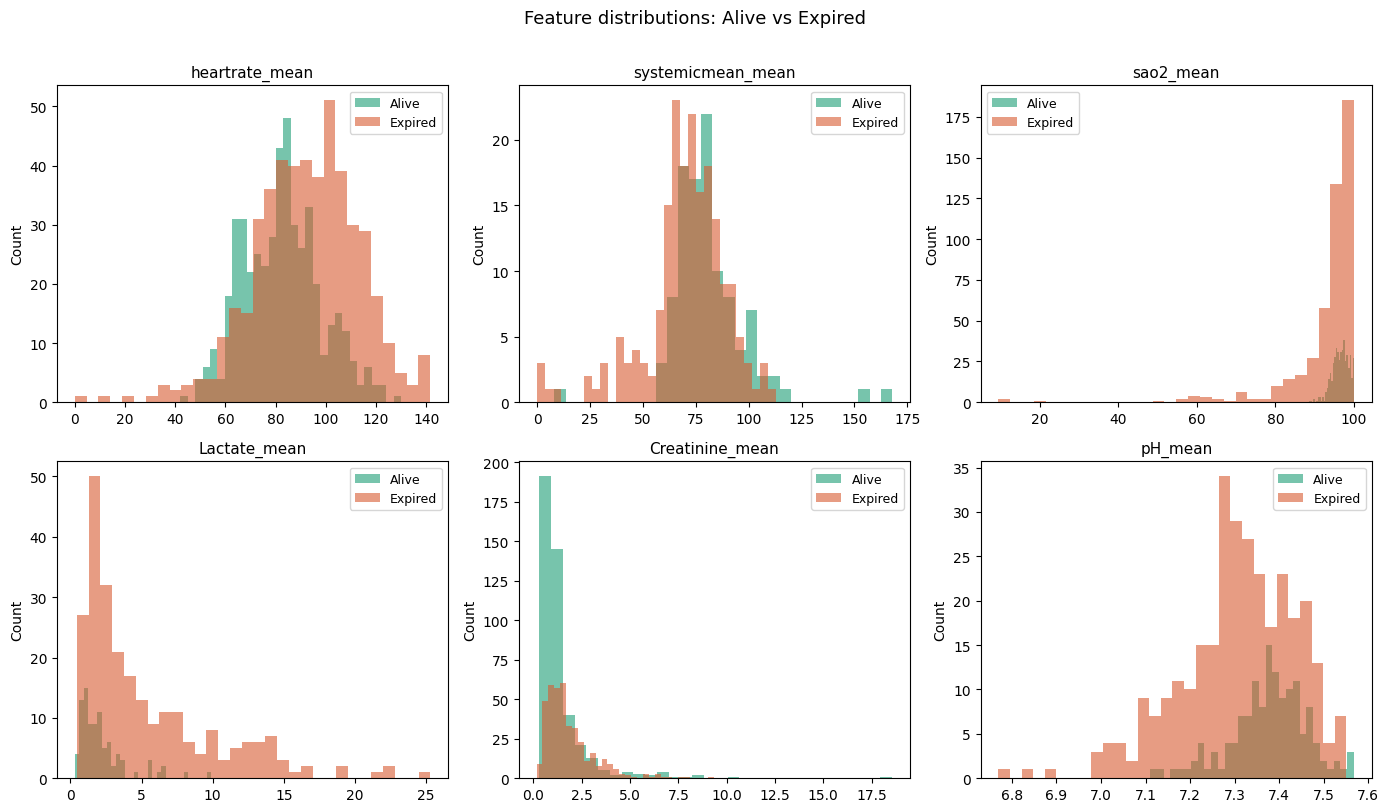

Plot saved to Drive.


In [ ]:
# Pick a handful of clinically meaningful features to eyeball
check_cols = [
    "heartrate_mean", "systemicmean_mean",
    "sao2_mean",      "Lactate_mean",
    "Creatinine_mean","pH_mean"
]

# Only plot columns that survived the 80% drop
check_cols = [c for c in check_cols if c in features.columns]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(check_cols):
    alive_vals   = features[features["unitdischargestatus"]=="Alive"][col].dropna()
    expired_vals = features[features["unitdischargestatus"]=="Expired"][col].dropna()

    axes[i].hist(alive_vals,   bins=30, alpha=0.6, label="Alive",   color="#1D9E75")
    axes[i].hist(expired_vals, bins=30, alpha=0.6, label="Expired", color="#D85A30")
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].set_ylabel("Count")

# Hide unused subplots
for j in range(len(check_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions: Alive vs Expired", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to Drive.")

Encoding, cleaning, and model training

In [ ]:
features = pd.read_csv(f"{OUT_DIR}/features.csv")

# Expired = 1 (the positive class we're predicting), Alive = 0
features["label"] = (features["unitdischargestatus"] == "Expired").astype(int)

#Drop columns not used as features
drop_cols = ["patientunitstayid", "unitdischargestatus"]
features  = features.drop(columns=drop_cols)

#Separate target from features
y = features["label"].copy()
X = features.drop(columns=["label"])

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

# Encode categoricals
# gender and ethnicity are strings — encode to integers
cat_cols = ["gender", "ethnicity"]
cat_cols = [c for c in cat_cols if c in X.columns]

for col in cat_cols:
    X[col] = X[col].fillna("Unknown")
    le      = LabelEncoder()
    X[col]  = le.fit_transform(X[col].astype(str))
    print(f"Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Impute missing numerics with median
# Median is preferred over mean for ICU data — resistant to outliers
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

imputer   = SimpleImputer(strategy="median")
X[num_cols] = imputer.fit_transform(X[num_cols])

print(f"\nMissing values after imputation: {X.isnull().sum().sum()}")

# Scale numeric features
# Required for Logistic Regression, good practice for all models
scaler      = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print(f"\nFinal X shape: {X.shape}")
print("Sample of processed features:")
print(X.head(3).to_string())

X shape: (1000, 69)
y distribution:
label
1    500
0    500
Name: count, dtype: int64
Encoded 'gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Unknown': np.int64(2)}
Encoded 'ethnicity': {'African American': np.int64(0), 'Asian': np.int64(1), 'Caucasian': np.int64(2), 'Hispanic': np.int64(3), 'Native American': np.int64(4), 'Other/Unknown': np.int64(5), 'Unknown': np.int64(6)}

Missing values after imputation: 0

Final X shape: (1000, 69)
Sample of processed features:
        age    gender  ethnicity  admissionheight  admissionweight  heartrate_mean  heartrate_min  heartrate_max  heartrate_last  systemicmean_mean  systemicmean_min  systemicmean_max  systemicmean_last  respiration_mean  respiration_min  respiration_max  respiration_last  sao2_mean  sao2_min  sao2_max  sao2_last  ALT_mean  AST_mean  BUN_mean  Bicarbonate_mean  Bilirubin_mean  Creatinine_mean  Lactate_mean  PaCO2_mean  PaO2_mean  Platelets_mean  WBC_mean   pH_mean   ALT_min   AST_min   BUN_min  Bicarbonate_min  Bil

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,          # 800 train, 200 test
    stratify     = y,            # preserve 50/50 balance in both splits
    random_state = RANDOM_SEED
)

print(f"Train: {X_train.shape[0]} patients")
print(f"Test : {X_test.shape[0]} patients")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

#Save processed arrays for easy reload
import joblib

joblib.dump(X_train, f"{OUT_DIR}/X_train.pkl")
joblib.dump(X_test,  f"{OUT_DIR}/X_test.pkl")
joblib.dump(y_train, f"{OUT_DIR}/y_train.pkl")
joblib.dump(y_test,  f"{OUT_DIR}/y_test.pkl")
joblib.dump(imputer, f"{OUT_DIR}/imputer.pkl")   # save for future inference
joblib.dump(scaler,  f"{OUT_DIR}/scaler.pkl")    # save for future inference

print("\nAll splits and preprocessors saved to Drive.")

Train: 800 patients
Test : 200 patients

Train label distribution:
label
1    400
0    400
Name: count, dtype: int64

Test label distribution:
label
1    100
0    100
Name: count, dtype: int64

All splits and preprocessors saved to Drive.


**LOGISTIC REGRESSION**

In [ ]:
X_train = joblib.load(f"{OUT_DIR}/X_train.pkl")
X_test  = joblib.load(f"{OUT_DIR}/X_test.pkl")
y_train = joblib.load(f"{OUT_DIR}/y_train.pkl")
y_test  = joblib.load(f"{OUT_DIR}/y_test.pkl")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

lr = LogisticRegression(
    max_iter    = 1000,
    C           = 1.0,       # regularization strength (1.0 = default)
    class_weight= "balanced",
    random_state= RANDOM_SEED
)

# 5 fold cross-validation on training set
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring="roc_auc")
print("Logistic Regression — 5-fold CV AUC:")
print(f"  Per fold : {lr_cv_scores.round(3)}")
print(f"  Mean ± SD: {lr_cv_scores.mean():.3f} ± {lr_cv_scores.std():.3f}")

# Fit on full training set
lr.fit(X_train, y_train)

# Test set AUC
lr_test_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f"  Test AUC : {lr_test_auc:.3f}")

joblib.dump(lr, f"{OUT_DIR}/model_lr.pkl")
print("Saved model_lr.pkl")

Logistic Regression — 5-fold CV AUC:
  Per fold : [0.83  0.897 0.821 0.77  0.826]
  Mean ± SD: 0.829 ± 0.040
  Test AUC : 0.856
Saved model_lr.pkl


**RANDOM FOREST**

In [ ]:
rf = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = None,      # grow full trees, let it learn complexity
    min_samples_leaf = 5,     # prevents overfitting on small ICU dataset
    class_weight = "balanced",
    random_state = RANDOM_SEED,
    n_jobs       = -1         # use all CPU cores
)

rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc")
print("Random Forest — 5-fold CV AUC:")
print(f"  Per fold : {rf_cv_scores.round(3)}")
print(f"  Mean ± SD: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}")

rf.fit(X_train, y_train)

rf_test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"  Test AUC : {rf_test_auc:.3f}")

joblib.dump(rf, f"{OUT_DIR}/model_rf.pkl")
print("Saved model_rf.pkl")

Random Forest — 5-fold CV AUC:
  Per fold : [0.869 0.929 0.855 0.886 0.84 ]
  Mean ± SD: 0.876 ± 0.031
  Test AUC : 0.882
Saved model_rf.pkl


**XG BOOST**

In [ ]:
xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,       # shallow trees reduce overfitting
    learning_rate     = 0.05,    # slow learning = better generalisation
    subsample         = 0.8,     # use 80% of rows per tree
    colsample_bytree  = 0.8,     # use 80% of features per tree
    scale_pos_weight  = 1,       # dataset is balanced so keep at 1
    eval_metric       = "auc",
    random_state      = RANDOM_SEED,
    n_jobs            = -1
)

xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="roc_auc")
print("XGBoost — 5-fold CV AUC:")
print(f"  Per fold : {xgb_cv_scores.round(3)}")
print(f"  Mean ± SD: {xgb_cv_scores.mean():.3f} ± {xgb_cv_scores.std():.3f}")

xgb.fit(X_train, y_train)

xgb_test_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"  Test AUC : {xgb_test_auc:.3f}")

joblib.dump(xgb, f"{OUT_DIR}/model_xgb.pkl")
print("Saved model_xgb.pkl")

XGBoost — 5-fold CV AUC:
  Per fold : [0.852 0.926 0.863 0.86  0.863]
  Mean ± SD: 0.873 ± 0.027
  Test AUC : 0.878
Saved model_xgb.pkl


COMPARISON OF MODELS

MODEL COMPARISON
              Model  CV AUC (mean)  CV AUC (±SD)  Test AUC
Logistic Regression          0.829         0.040     0.856
      Random Forest          0.876         0.031     0.882
            XGBoost          0.873         0.027     0.878


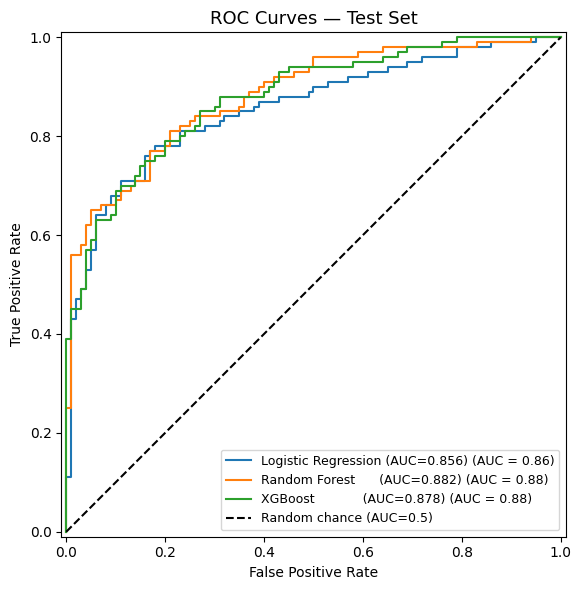

ROC curve saved to Drive.


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "CV AUC (mean)": [
        lr_cv_scores.mean(),
        rf_cv_scores.mean(),
        xgb_cv_scores.mean()
    ],
    "CV AUC (±SD)": [
        lr_cv_scores.std(),
        rf_cv_scores.std(),
        xgb_cv_scores.std()
    ],
    "Test AUC": [lr_test_auc, rf_test_auc, xgb_test_auc]
}).round(3)

print("=" * 55)
print("MODEL COMPARISON")
print("=" * 55)
print(results.to_string(index=False))
print("=" * 55)

#ROC curves for all three on test set
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    lr,  X_test, y_test, ax=ax, name=f"Logistic Regression (AUC={lr_test_auc:.3f})"
)
RocCurveDisplay.from_estimator(
    rf,  X_test, y_test, ax=ax, name=f"Random Forest      (AUC={rf_test_auc:.3f})"
)
RocCurveDisplay.from_estimator(
    xgb, X_test, y_test, ax=ax, name=f"XGBoost            (AUC={xgb_test_auc:.3f})"
)

ax.plot([0, 1], [0, 1], "k--", label="Random chance (AUC=0.5)")
ax.set_title("ROC Curves — Test Set", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("ROC curve saved to Drive.")

Top 20 most important features:
sao2_min            0.0774
pH_min              0.0452
sao2_last           0.0401
heartrate_last      0.0393
heartrate_min       0.0378
sao2_mean           0.0364
pH_mean             0.0357
heartrate_max       0.0315
heartrate_mean      0.0278
Bicarbonate_min     0.0259
pH_last             0.0241
Lactate_min         0.0230
Lactate_mean        0.0217
Creatinine_mean     0.0212
BUN_mean            0.0189
Bicarbonate_last    0.0176
BUN_max             0.0175
Lactate_last        0.0173
BUN_last            0.0166
respiration_last    0.0163


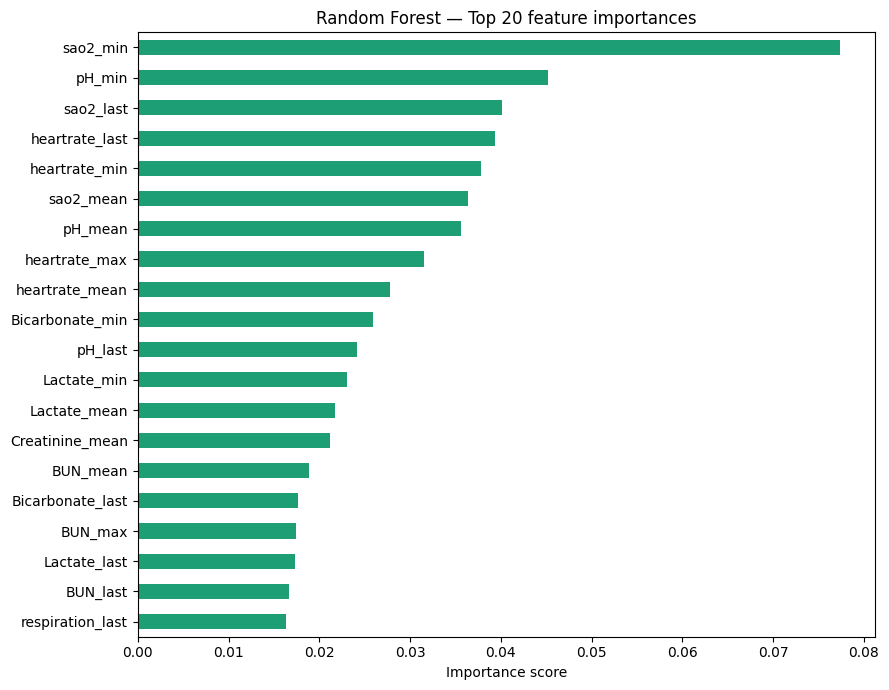

In [ ]:
# If last-value features are the most important ones,
# that confirms the model is exploiting end-of-stay data
rf  = joblib.load(f"{OUT_DIR}/model_rf.pkl")
X_train = joblib.load(f"{OUT_DIR}/X_train.pkl")

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 20 most important features:")
print(importance.head(20).round(4).to_string())

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
importance.head(20).plot(kind="barh", ax=ax, color="#1D9E75")
ax.invert_yaxis()
ax.set_title("Random Forest — Top 20 feature importances", fontsize=12)
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importance_leakage_check.png",
            dpi=120, bbox_inches="tight")
plt.show()

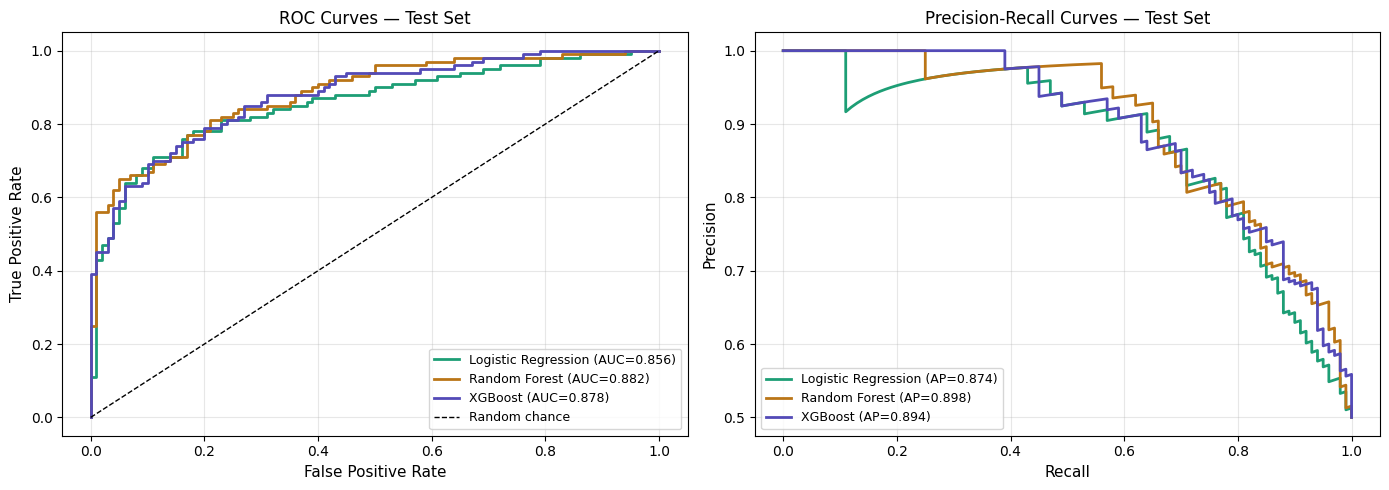

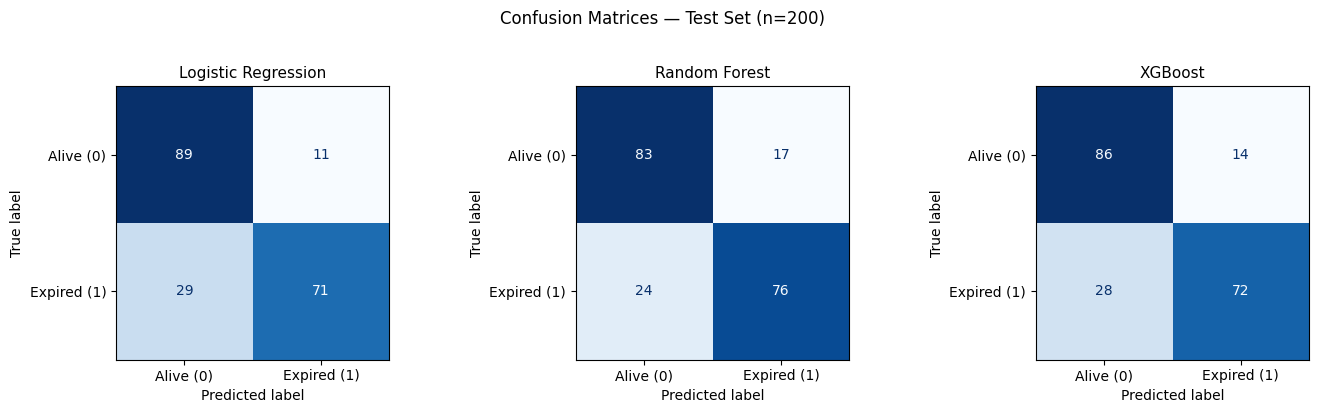


=== Random Forest — Full Classification Report ===
              precision    recall  f1-score   support

       Alive       0.78      0.83      0.80       100
     Expired       0.82      0.76      0.79       100

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



In [ ]:
# Load everything
lr      = joblib.load(f"{OUT_DIR}/model_lr.pkl")
rf      = joblib.load(f"{OUT_DIR}/model_rf.pkl")
xgb     = joblib.load(f"{OUT_DIR}/model_xgb.pkl")
X_train = joblib.load(f"{OUT_DIR}/X_train.pkl")
X_test  = joblib.load(f"{OUT_DIR}/X_test.pkl")
y_train = joblib.load(f"{OUT_DIR}/y_train.pkl")
y_test  = joblib.load(f"{OUT_DIR}/y_test.pkl")

models      = {"Logistic Regression": lr, "Random Forest": rf, "XGBoost": xgb}
colors      = {"Logistic Regression": "#1D9E75",
               "Random Forest":       "#BA7517",
               "XGBoost":             "#534AB7"}

#ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_roc = axes[0]
for name, model in models.items():
    y_prob       = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _  = roc_curve(y_test, y_prob)
    auc          = roc_auc_score(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})",
                color=colors[name], linewidth=2)

ax_roc.plot([0,1],[0,1], "k--", linewidth=1, label="Random chance")
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate", fontsize=11)
ax_roc.set_title("ROC Curves — Test Set", fontsize=12)
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

#Precision-Recall curve (better for medical context)
from sklearn.metrics import precision_recall_curve, average_precision_score

ax_pr = axes[1]
for name, model in models.items():
    y_prob        = model.predict_proba(X_test)[:, 1]
    prec, rec, _  = precision_recall_curve(y_test, y_prob)
    ap            = average_precision_score(y_test, y_prob)
    ax_pr.plot(rec, prec, label=f"{name} (AP={ap:.3f})",
               color=colors[name], linewidth=2)

ax_pr.set_xlabel("Recall", fontsize=11)
ax_pr.set_ylabel("Precision", fontsize=11)
ax_pr.set_title("Precision-Recall Curves — Test Set", fontsize=12)
ax_pr.legend(fontsize=9)
ax_pr.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Confusion matrices for all three
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=["Alive (0)", "Expired (1)"]
             )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=11)

plt.suptitle("Confusion Matrices — Test Set (n=200)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

#Full classification report for best model (RF)
print("\n=== Random Forest — Full Classification Report ===")
print(classification_report(
    y_test,
    rf.predict(X_test),
    target_names=["Alive", "Expired"]
))

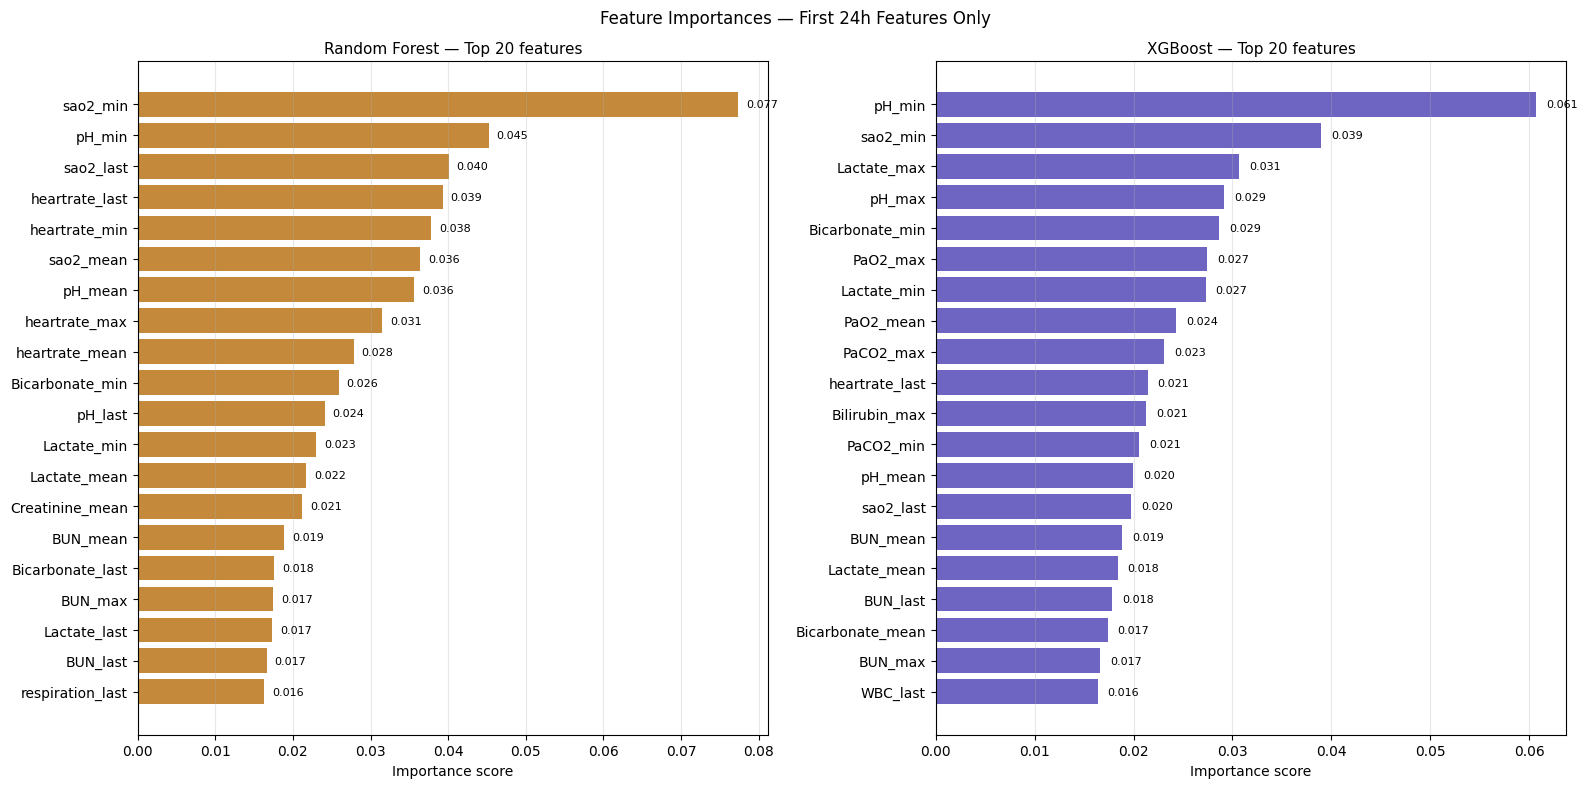

Top 10 features — Random Forest:
sao2_min           0.0774
pH_min             0.0452
sao2_last          0.0401
heartrate_last     0.0393
heartrate_min      0.0378
sao2_mean          0.0364
pH_mean            0.0357
heartrate_max      0.0315
heartrate_mean     0.0278
Bicarbonate_min    0.0259


In [ ]:
#Feature importance (RF + XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (name, model) in zip(axes, {
    "Random Forest": rf,
    "XGBoost":       xgb
}.items()):
    importance = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=True).tail(20)

    bars = ax.barh(importance.index, importance.values,
                   color=colors[name], alpha=0.85)
    ax.set_title(f"{name} — Top 20 features", fontsize=11)
    ax.set_xlabel("Importance score", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

    # Add value labels on bars
    for bar, val in zip(bars, importance.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

plt.suptitle("Feature Importances — First 24h Features Only", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

# Print top 10 for RF
print("Top 10 features — Random Forest:")
rf_imp = pd.Series(rf.feature_importances_,
                   index=X_train.columns).sort_values(ascending=False)
print(rf_imp.head(10).round(4).to_string())

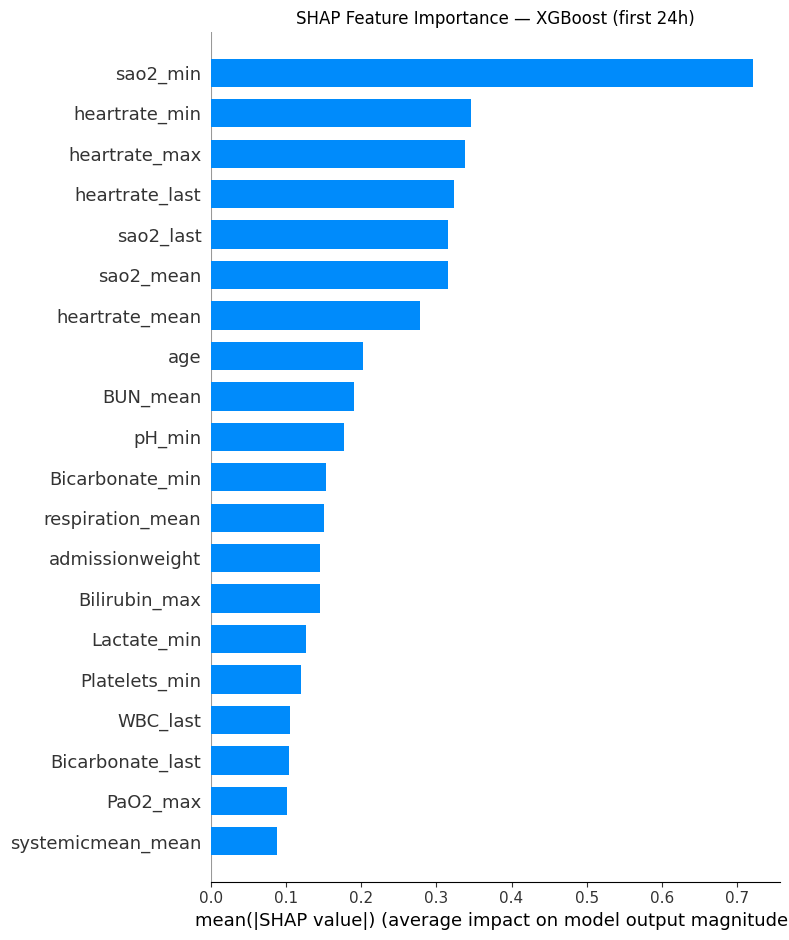

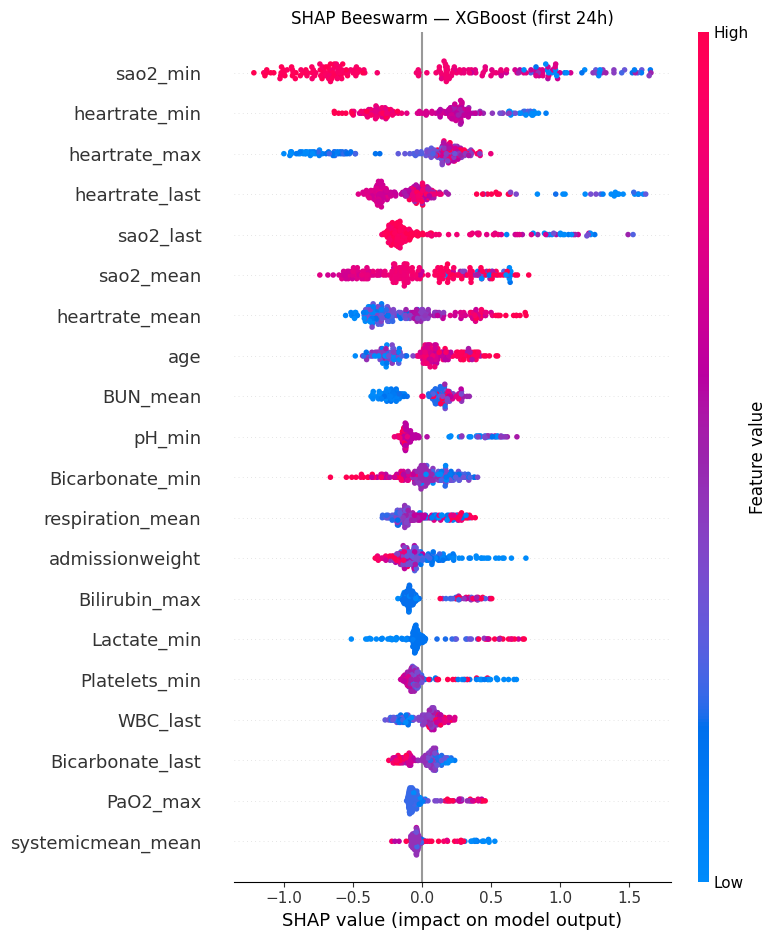


Explaining prediction for patient index 810
True label : Expired
Predicted probability of death: 0.893


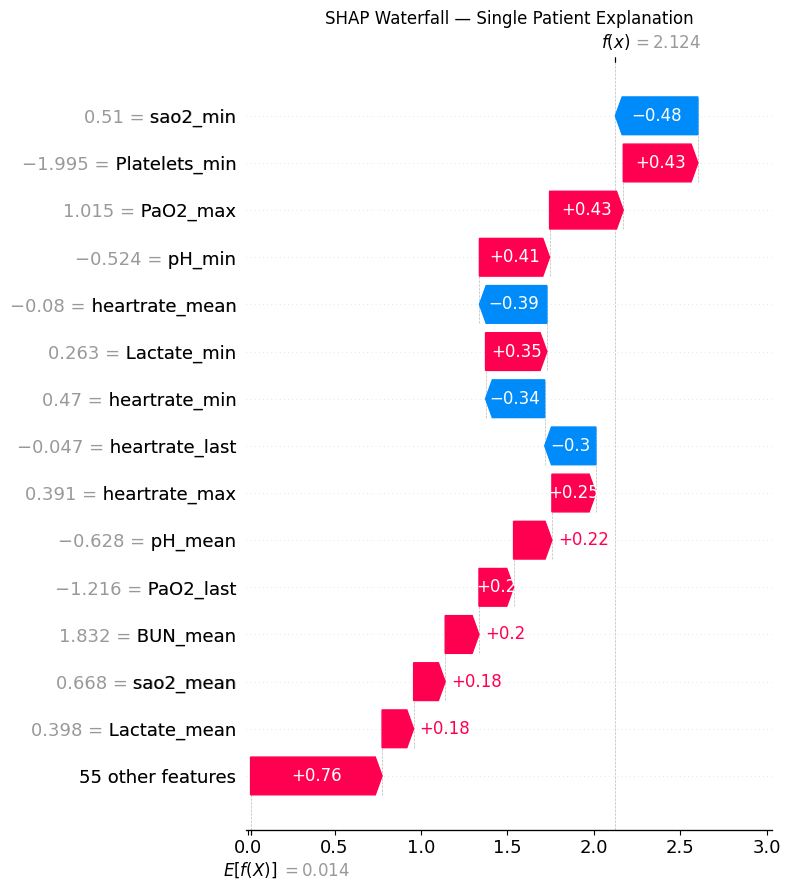

In [ ]:
# Use XGBoost for SHAP
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot (global feature importance)
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    plot_type = "bar",
    max_display = 20,
    show = False
)
plt.title("SHAP Feature Importance — XGBoost (first 24h)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_importance.png", dpi=120, bbox_inches="tight")
plt.show()

# SHAP beeswarm plot (direction + magnitude)
# This shows not just WHAT matters but HOW it affects prediction
plt.figure()
shap.summary_plot(
    shap_values, X_test,
    max_display = 20,
    show = False
)
plt.title("SHAP Beeswarm — XGBoost (first 24h)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

# SHAP waterfall for a single patient
# Pick one expired patient and explain WHY the model predicted death
expired_indices = y_test[y_test == 1].index
sample_idx      = expired_indices[0]
sample_pos      = X_test.index.get_loc(sample_idx)

print(f"\nExplaining prediction for patient index {sample_idx}")
print(f"True label : {'Expired' if y_test[sample_idx]==1 else 'Alive'}")
print(f"Predicted probability of death: "
      f"{xgb.predict_proba(X_test)[sample_pos, 1]:.3f}")

shap.waterfall_plot(
    shap.Explanation(
        values    = shap_values[sample_pos],
        base_values = explainer.expected_value,
        data      = X_test.iloc[sample_pos],
        feature_names = X_test.columns.tolist()
    ),
    max_display = 15,
    show = False
)
plt.title("SHAP Waterfall — Single Patient Explanation", fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/shap_waterfall.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score
)

rows = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    rows.append({
        "Model":      name,
        "AUC-ROC":    round(roc_auc_score(y_test, y_prob), 3),
        "Accuracy":   round(accuracy_score(y_test, y_pred), 3),
        "Precision":  round(precision_score(y_test, y_pred), 3),
        "Recall":     round(recall_score(y_test, y_pred), 3),
        "F1 Score":   round(f1_score(y_test, y_pred), 3),
    })

summary = pd.DataFrame(rows)
print("=" * 65)
print("FINAL MODEL EVALUATION SUMMARY — First 24h Features")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)
print("\nAll plots saved to Drive.")
print("Project complete.")

FINAL MODEL EVALUATION SUMMARY — First 24h Features
              Model  AUC-ROC  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.856     0.800      0.866    0.71     0.780
      Random Forest    0.882     0.795      0.817    0.76     0.788
            XGBoost    0.878     0.790      0.837    0.72     0.774

All plots saved to Drive.
Project complete.
